In [1]:
from sklearn.datasets import make_moons, make_circles, load_digits
import numpy as np
from matplotlib import pyplot as plt

## Make moons dataset

In [2]:
from src.golem.Pipeline import Pipeline
from sklearn.metrics import accuracy_score

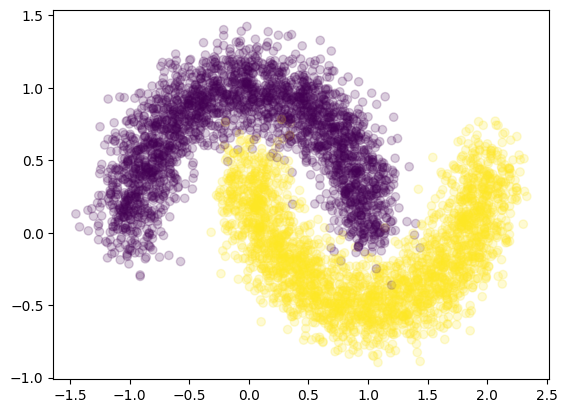

In [3]:
X,y = make_moons(n_samples=5000, noise=0.15, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)

In [4]:
from src.golem.Pipeline import Pipeline
from sklearn.metrics import accuracy_score
pipeline = Pipeline(X, y, multiclass=False)
pipeline.get_data(train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=256)

In [5]:
mlp_model, mlp_acc = pipeline.fit_mlp(epochs=40, depth=12, hidden_dim=64, learning_rate=1e-3)
print(f"MLP Test Accuracy: {mlp_acc}%")

Epoch 1/40
Accuracy: 0.505
Epoch 2/40
Accuracy: 0.505
Epoch 3/40
Accuracy: 0.891
Epoch 4/40
Accuracy: 0.902
Epoch 5/40
Accuracy: 0.945
Epoch 6/40
Accuracy: 0.956
Epoch 7/40
Accuracy: 0.985
Epoch 8/40
Accuracy: 0.991
Epoch 9/40
Accuracy: 0.985
Epoch 10/40
Accuracy: 0.986
Epoch 11/40
Accuracy: 0.988
Epoch 12/40
Accuracy: 0.989
Epoch 13/40
Accuracy: 0.991
Epoch 14/40
Accuracy: 0.992
Epoch 15/40
Accuracy: 0.995
Epoch 16/40
Accuracy: 0.993
Epoch 17/40
Accuracy: 0.992
Epoch 18/40
Accuracy: 0.988
Epoch 19/40
Accuracy: 0.989
Epoch 20/40
Accuracy: 0.989
Epoch 21/40
Accuracy: 0.99
Epoch 22/40
Accuracy: 0.993
Epoch 23/40
Accuracy: 0.991
Epoch 24/40
Accuracy: 0.991
Epoch 25/40
Accuracy: 0.994
Epoch 26/40
Accuracy: 0.99
Epoch 27/40
Accuracy: 0.993
Epoch 28/40
Accuracy: 0.993
Epoch 29/40
Accuracy: 0.987
Epoch 30/40
Accuracy: 0.988
Epoch 31/40
Accuracy: 0.99
Epoch 32/40
Accuracy: 0.991
Epoch 33/40
Accuracy: 0.989
Epoch 34/40
Accuracy: 0.991
Epoch 35/40
Accuracy: 0.991
Epoch 36/40
Accuracy: 0.995
Epoc

Embedding shape: (3000, 32)


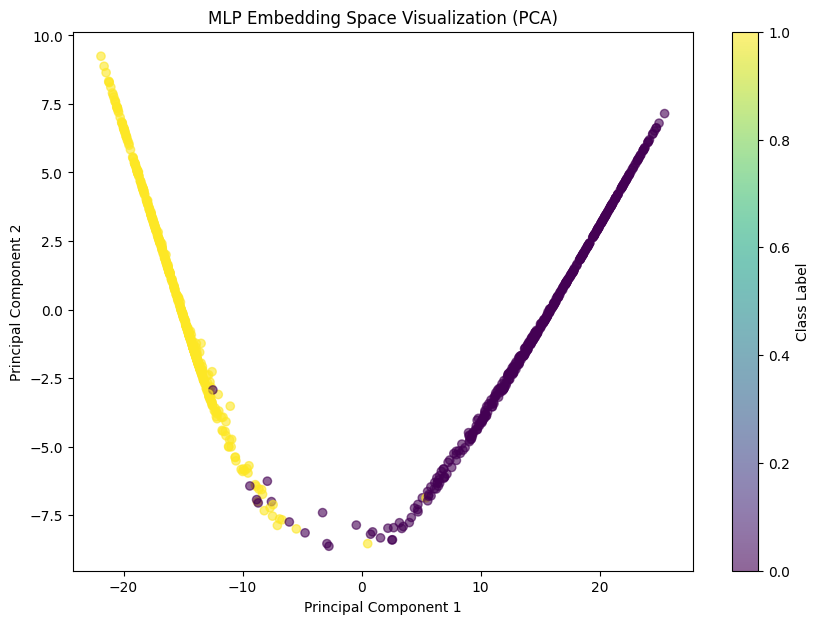

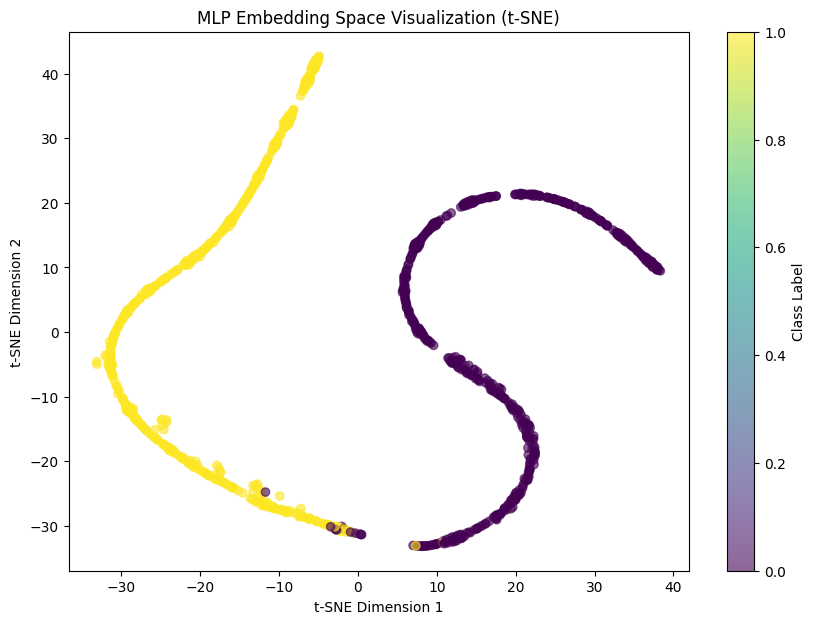

In [10]:
pipeline.extract_embeddings()
print(f"Embedding shape: {pipeline.embedings[0].shape}")
pipeline.embedding_visualization_pca()
pipeline.embedding_visualization_tsne()

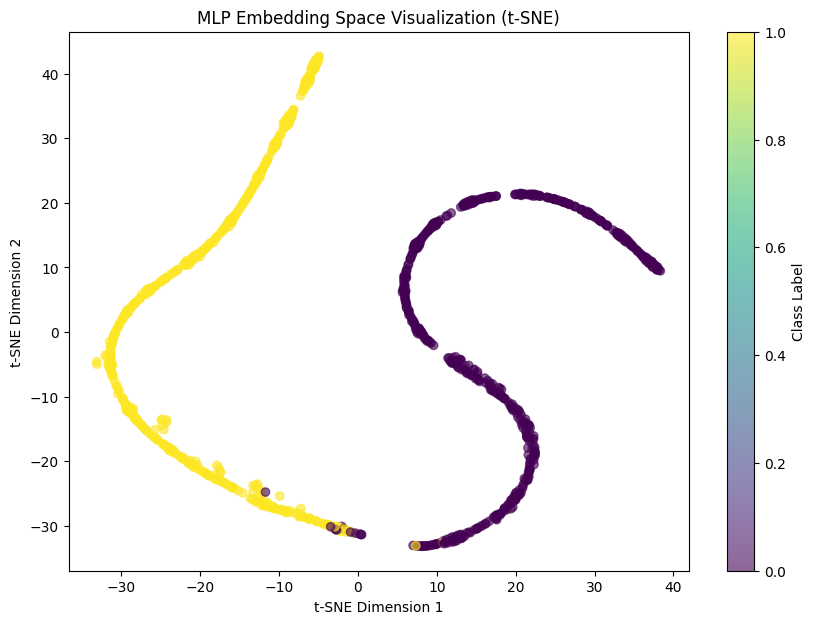

In [ ]:
rf_simple, rf_simple_score = pipeline.train_random_forest(use_embeddings=False)
rf_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_simple.predict(pipeline.X_sa_part[2]))
print(f"RFAccuracy: {rf_simple_test_acc}")
dt_simple, dt_simple_score = pipeline.train_decision_tree(use_embeddings=False)
dt_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_simple.predict(pipeline.X_sa_part[2]))
print(f"Decision Tree (Simple) Test Accuracy: {dt_simple_test_acc}")
gb_simple, gb_simple_score = pipeline.train_gradient_boosting(use_embeddings=False)
gb_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_simple.predict(pipeline.X_sa_part[2]))
print(f"Gradient Boosting (Simple) Test Accuracy: {gb_simple_test_acc}")

RFAccuracy: 0.99


In [ ]:
rf_hybrid, rf_hybrid_score = pipeline.train_random_forest(use_embeddings=True)
rf_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_hybrid.predict(pipeline.embedings[2]))
print(f"embedings+RF Accuracy: {rf_hybrid_test_acc}")
dt_hybrid, dt_hybrid_score = pipeline.train_decision_tree(use_embeddings=True)
dt_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_hybrid.predict(pipeline.embedings[2]))
print(f"Decision Tree (Hybrid) Test Accuracy: {dt_hybrid_test_acc}")
gb_hybrid, gb_hybrid_score = pipeline.train_gradient_boosting(use_embeddings=True)
gb_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_hybrid.predict(pipeline.embedings[2]))
print(f"Gradient Boosting (Hybrid) Test Accuracy: {gb_hybrid_test_acc}")

embedings+RF Accuracy: 0.48


#### Results Comparison

In [33]:
print(f"MLP Only: {mlp_acc}%")
print(f"Random Forest (Simple): {rf_simple_test_acc}")
print(f"Random Forest (Hybrid - MLP + RF): {rf_hybrid_test_acc}")
print(f"Decision Tree (Simple): {dt_simple_test_acc}")
print(f"Decision Tree (Hybrid - MLP + DT): {dt_hybrid_test_acc}")
print(f"Gradient Boosting (Simple): {gb_simple_test_acc}")
print(f"Gradient Boosting (Hybrid - MLP + GB): {gb_hybrid_test_acc}")

MLP Only: 0.988%
Random Forest (Simple): 0.99
Random Forest (Hybrid - MLP + RF): 0.517
Decision Tree (Simple): 0.985
Decision Tree (Hybrid - MLP + DT): 0.517
Gradient Boosting (Simple): 0.991
Gradient Boosting (Hybrid - MLP + GB): 0.547


## Make circles dataset

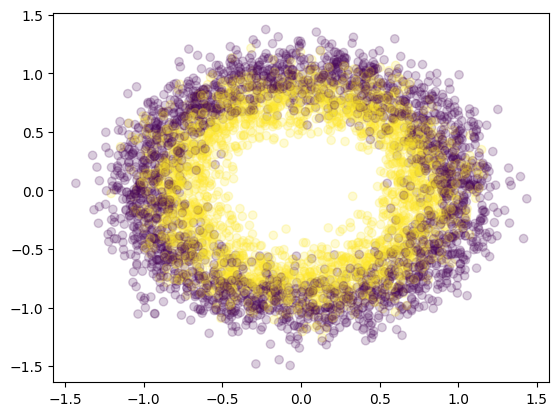

In [15]:
X,y = make_circles(n_samples=5000, noise=0.15, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)

In [16]:
import importlib
import src.golem.Pipeline
importlib.reload(src.golem.Pipeline)
from src.golem.Pipeline import Pipeline

In [17]:
from sklearn.metrics import accuracy_score
pipeline = Pipeline(X, y, multiclass=False)
pipeline.get_data(train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=256)

In [18]:
mlp_model, mlp_acc = pipeline.fit_mlp(epochs=40, depth=12, hidden_dim=64, learning_rate=1e-3)
print(f"MLP Test Accuracy: {mlp_acc}")

Epoch 1/40
Accuracy: 0.495
Epoch 2/40
Accuracy: 0.505
Epoch 3/40
Accuracy: 0.505
Epoch 4/40
Accuracy: 0.749
Epoch 5/40
Accuracy: 0.71
Epoch 6/40
Accuracy: 0.737
Epoch 7/40
Accuracy: 0.748
Epoch 8/40
Accuracy: 0.753
Epoch 9/40
Accuracy: 0.745
Epoch 10/40
Accuracy: 0.735
Epoch 11/40
Accuracy: 0.751
Epoch 12/40
Accuracy: 0.75
Epoch 13/40
Accuracy: 0.753
Epoch 14/40
Accuracy: 0.747
Epoch 15/40
Accuracy: 0.744
Epoch 16/40
Accuracy: 0.743
Epoch 17/40
Accuracy: 0.745
Epoch 18/40
Accuracy: 0.751
Epoch 19/40
Accuracy: 0.751
Epoch 20/40
Accuracy: 0.755
Epoch 21/40
Accuracy: 0.744
Epoch 22/40
Accuracy: 0.734
Epoch 23/40
Accuracy: 0.744
Epoch 24/40
Accuracy: 0.747
Epoch 25/40
Accuracy: 0.753
Epoch 26/40
Accuracy: 0.756
Epoch 27/40
Accuracy: 0.755
Epoch 28/40
Accuracy: 0.749
Epoch 29/40
Accuracy: 0.755
Epoch 30/40
Accuracy: 0.746
Epoch 31/40
Accuracy: 0.748
Epoch 32/40
Accuracy: 0.744
Epoch 33/40
Accuracy: 0.744
Epoch 34/40
Accuracy: 0.756
Epoch 35/40
Accuracy: 0.751
Epoch 36/40
Accuracy: 0.749
Epo

In [19]:
rf_simple, rf_simple_score = pipeline.train_random_forest(use_embeddings=False)
rf_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_simple.predict(pipeline.X_sa_part[2]))
print(f"RFAccuracy: {rf_simple_test_acc}")
dt_simple, dt_simple_score = pipeline.train_decision_tree(use_embeddings=False)
dt_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_simple.predict(pipeline.X_sa_part[2]))
print(f"Decision Tree (Simple) Test Accuracy: {dt_simple_test_acc}")
gb_simple, gb_simple_score = pipeline.train_gradient_boosting(use_embeddings=False)
gb_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_simple.predict(pipeline.X_sa_part[2]))
print(f"Gradient Boosting (Simple) Test Accuracy: {gb_simple_test_acc}")

RFAccuracy: 0.7
Decision Tree (Simple) Test Accuracy: 0.637
Gradient Boosting (Simple) Test Accuracy: 0.72


Embedding shape: (3000, 32)


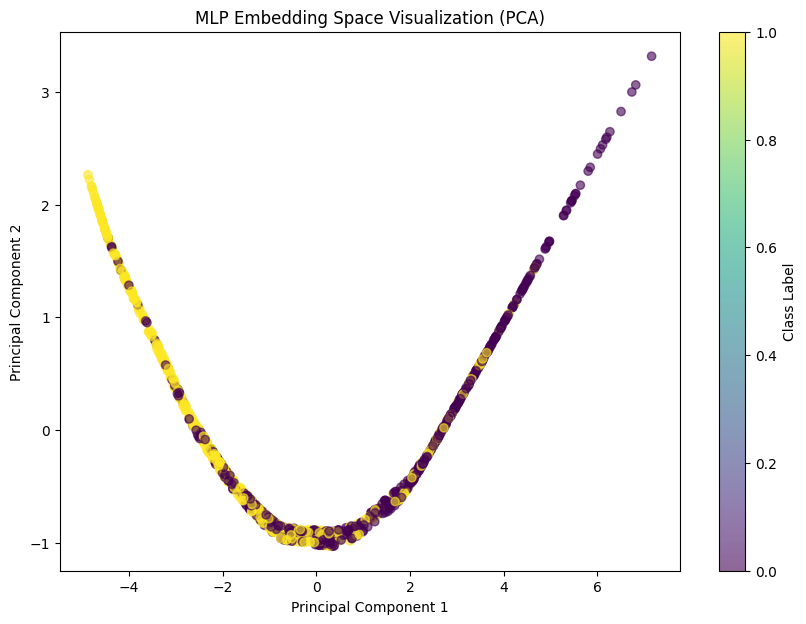

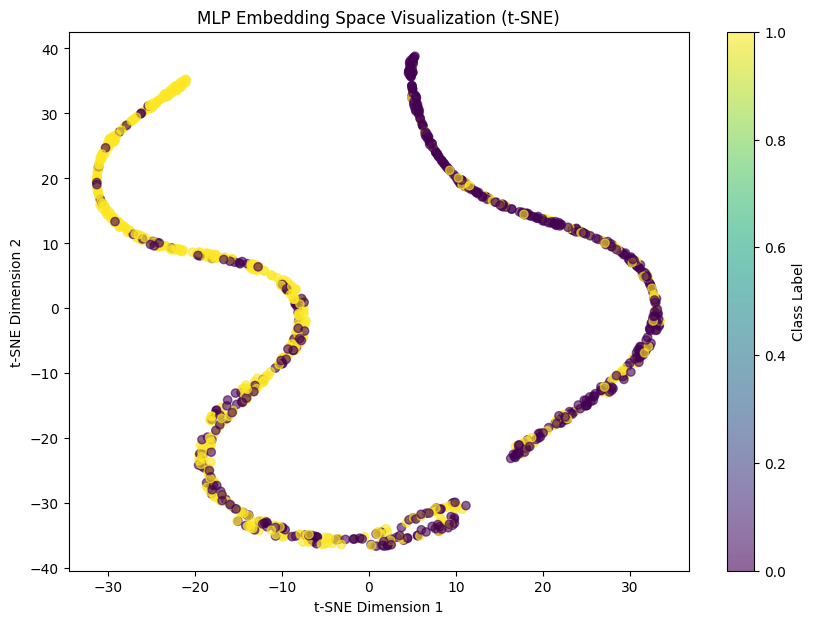

In [20]:
pipeline.extract_embeddings()
print(f"Embedding shape: {pipeline.embedings[0].shape}")
pipeline.embedding_visualization_pca()
pipeline.embedding_visualization_tsne()

In [21]:


rf_hybrid, rf_hybrid_score = pipeline.train_random_forest(use_embeddings=True)
rf_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_hybrid.predict(pipeline.embedings[2]))
print(f"embedings+RF Accuracy: {rf_hybrid_test_acc}")
dt_hybrid, dt_hybrid_score = pipeline.train_decision_tree(use_embeddings=True)
dt_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_hybrid.predict(pipeline.embedings[2]))
print(f"Decision Tree (Hybrid) Test Accuracy: {dt_hybrid_test_acc}")
gb_hybrid, gb_hybrid_score = pipeline.train_gradient_boosting(use_embeddings=True)
gb_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_hybrid.predict(pipeline.embedings[2]))
print(f"Gradient Boosting (Hybrid) Test Accuracy: {gb_hybrid_test_acc}")

embedings+RF Accuracy: 0.489
Decision Tree (Hybrid) Test Accuracy: 0.488
Gradient Boosting (Hybrid) Test Accuracy: 0.419


#### Comparison

In [22]:
print(f"MLP Only: {mlp_acc}%")
print(f"Random Forest (Simple): {rf_simple_test_acc}")
print(f"Random Forest (Hybrid - MLP + RF): {rf_hybrid_test_acc}")
print(f"Decision Tree (Simple): {dt_simple_test_acc}")
print(f"Decision Tree (Hybrid - MLP + DT): {dt_hybrid_test_acc}")
print(f"Gradient Boosting (Simple): {gb_simple_test_acc}")
print(f"Gradient Boosting (Hybrid - MLP + GB): {gb_hybrid_test_acc}")

MLP Only: 0.73%
Random Forest (Simple): 0.7
Random Forest (Hybrid - MLP + RF): 0.489
Decision Tree (Simple): 0.637
Decision Tree (Hybrid - MLP + DT): 0.488
Gradient Boosting (Simple): 0.72
Gradient Boosting (Hybrid - MLP + GB): 0.419


## Digits dataset

In [23]:
X, y = load_digits(return_X_y=True)

In [24]:
import importlib
import src.golem.Pipeline
importlib.reload(src.golem.Pipeline)
from src.golem.Pipeline import Pipeline
from sklearn.metrics import accuracy_score
pipeline = Pipeline(X, y, multiclass=True)
pipeline.get_data(train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, batch_size=2048)

In [25]:
mlp_model, mlp_acc = pipeline.fit_mlp(epochs=400, out_dim=10,depth=12 ,hidden_dim=512 ,learning_rate=1e-4)
print(f"MLP Test Accuracy: {mlp_acc}")

Epoch 1/400
Accuracy: 0.14206128133704735
Epoch 2/400
Accuracy: 0.14206128133704735
Epoch 3/400
Accuracy: 0.14206128133704735
Epoch 4/400
Accuracy: 0.14206128133704735
Epoch 5/400
Accuracy: 0.14206128133704735
Epoch 6/400
Accuracy: 0.14206128133704735
Epoch 7/400
Accuracy: 0.14206128133704735
Epoch 8/400
Accuracy: 0.14206128133704735
Epoch 9/400
Accuracy: 0.14206128133704735
Epoch 10/400
Accuracy: 0.14484679665738162
Epoch 11/400
Accuracy: 0.22562674094707522
Epoch 12/400
Accuracy: 0.23676880222841226
Epoch 13/400
Accuracy: 0.23119777158774374
Epoch 14/400
Accuracy: 0.23119777158774374
Epoch 15/400
Accuracy: 0.23119777158774374
Epoch 16/400
Accuracy: 0.28133704735376047
Epoch 17/400
Accuracy: 0.28690807799442897
Epoch 18/400
Accuracy: 0.26740947075208915
Epoch 19/400
Accuracy: 0.2395543175487465
Epoch 20/400
Accuracy: 0.22841225626740946
Epoch 21/400
Accuracy: 0.22841225626740946
Epoch 22/400
Accuracy: 0.22841225626740946
Epoch 23/400
Accuracy: 0.23119777158774374
Epoch 24/400
Accuracy

In [26]:
rf_simple, rf_simple_score = pipeline.train_random_forest(use_embeddings=False)
rf_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_simple.predict(pipeline.X_sa_part[2]))
print(f"RFAccuracy: {rf_simple_test_acc}")
dt_simple, dt_simple_score = pipeline.train_decision_tree(use_embeddings=False)
dt_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_simple.predict(pipeline.X_sa_part[2]))
print(f"Decision Tree (Simple) Test Accuracy: {dt_simple_test_acc}")
gb_simple, gb_simple_score = pipeline.train_gradient_boosting(use_embeddings=False)
gb_simple_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_simple.predict(pipeline.X_sa_part[2]))
print(f"Gradient Boosting (Simple) Test Accuracy: {gb_simple_test_acc}")

RFAccuracy: 0.9722222222222222
Decision Tree (Simple) Test Accuracy: 0.8583333333333333
Gradient Boosting (Simple) Test Accuracy: 0.9638888888888889


Embedding shape: (1078, 256)


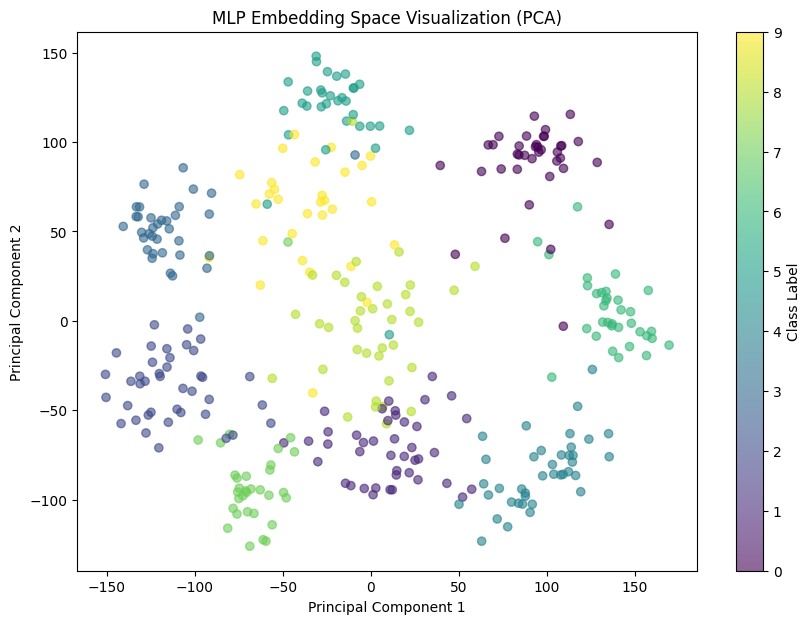

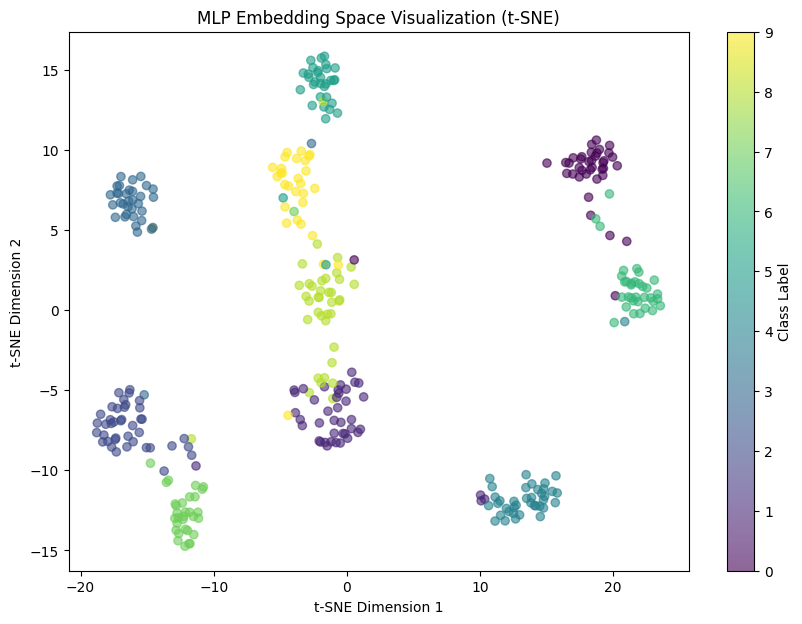

In [27]:
pipeline.extract_embeddings()
print(f"Embedding shape: {pipeline.embedings[0].shape}")
pipeline.embedding_visualization_pca()
pipeline.embedding_visualization_tsne()

In [28]:
rf_hybrid, rf_hybrid_score = pipeline.train_random_forest(use_embeddings=True)
rf_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], rf_hybrid.predict(pipeline.embedings[2]))
print(f"embedings+RF Accuracy: {rf_hybrid_test_acc}")
dt_hybrid, dt_hybrid_score = pipeline.train_decision_tree(use_embeddings=True)
dt_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], dt_hybrid.predict(pipeline.embedings[2]))
print(f"Decision Tree (Hybrid) Test Accuracy: {dt_hybrid_test_acc}")
gb_hybrid, gb_hybrid_score = pipeline.train_gradient_boosting(use_embeddings=True)
gb_hybrid_test_acc = accuracy_score(pipeline.y_sa_part[2], gb_hybrid.predict(pipeline.embedings[2]))
print(f"Gradient Boosting (Hybrid) Test Accuracy: {gb_hybrid_test_acc}")

embedings+RF Accuracy: 0.07777777777777778
Decision Tree (Hybrid) Test Accuracy: 0.09722222222222222
Gradient Boosting (Hybrid) Test Accuracy: 0.08611111111111111
